In [12]:
# Automatically install tdgl from GitHub only if running in Google Colab
if "google.colab" in str(get_ipython()):
    %pip install --quiet git+https://github.com/loganbvh/py-tdgl.git
    !apt install ffmpeg

In [14]:
%config InlineBackend.figure_formats = {"retina", "png"}

import os
import tempfile

os.environ["OPENBLAS_NUM_THREADS"] = "1"

from IPython.display import HTML, display
import h5py
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (5, 4)

import tdgl
from tdgl.geometry import box, circle
from tdgl.visualization.animate import create_animation

In [16]:
MAKE_ANIMATIONS = True
tempdir = tempfile.TemporaryDirectory()

In [18]:
def make_video_from_solution(
    solution,
    quantities=("order_parameter", "phase"),
    fps=20,
    figsize=(5, 4),
):
    """Generates an HTML5 video from a tdgl.Solution."""
    with tdgl.non_gui_backend():
        with h5py.File(solution.path, "r") as h5file:
            anim = create_animation(
                h5file,
                quantities=quantities,
                fps=fps,
                figure_kwargs=dict(figsize=figsize),
            )
            video = anim.to_html5_video()
        return HTML(video)

In [20]:
length_units = "nm"
# Material parameters
xi = 10.5
london_lambda = 74.7
d = 25
layer = tdgl.Layer(coherence_length=xi, london_lambda=london_lambda, thickness=d, gamma=1)

# Device geometry
total_width = 1024
total_length = 1024

film = (
    tdgl.Polygon("film", points=box(total_width, total_length))
    .resample(401)
    .buffer(0)
)
# Current terminals
source = (
    tdgl.Polygon("source", points=box(1.1 * total_width, total_length / 100))
    .translate(dy=total_length / 2)
)
drain = source.scale(yfact=-1).set_name("drain")

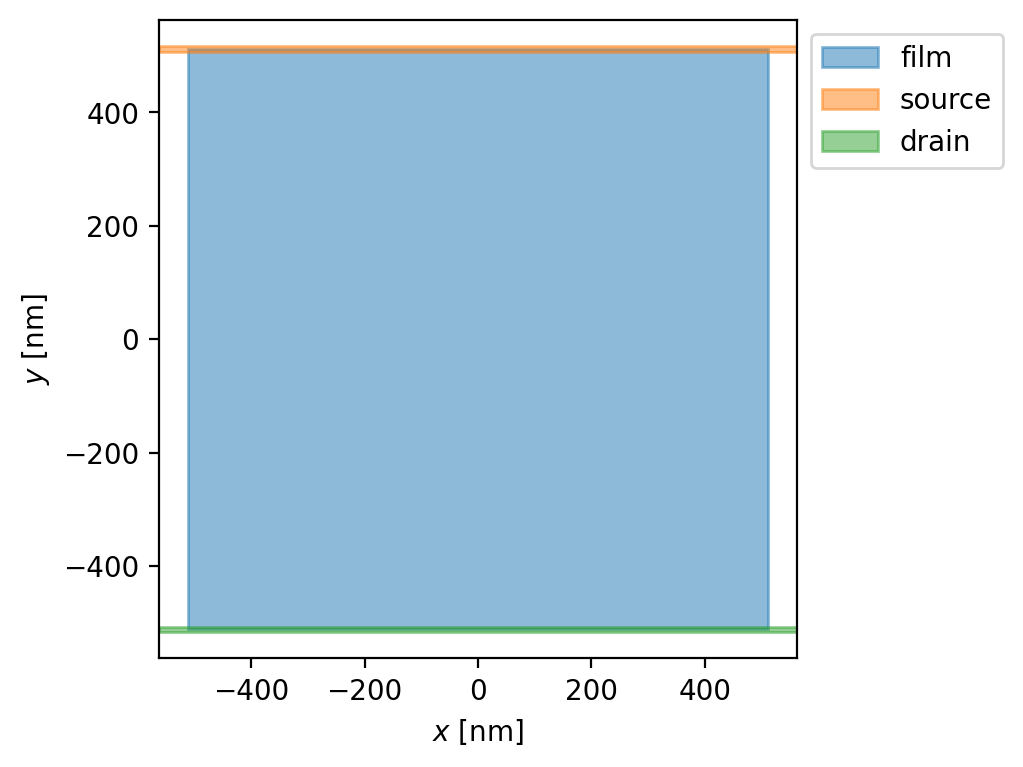

In [22]:
device = tdgl.Device(
    "square",
    layer=layer,
    film=film,
    terminals=[source,drain],
    length_units=length_units,
)
fig, ax = device.draw()

Constructing Voronoi polygons:   0%|          | 0/132751 [00:00<?, ?it/s]Malformed Voronoi cell surrounding boundary site 11. Try changing the number of boundary mesh sites using Polygon.resample() or Polygon.buffer(eps) where eps is 0 or a small positive float.
Malformed Voronoi cell surrounding boundary site 12. Try changing the number of boundary mesh sites using Polygon.resample() or Polygon.buffer(eps) where eps is 0 or a small positive float.
Malformed Voronoi cell surrounding boundary site 15. Try changing the number of boundary mesh sites using Polygon.resample() or Polygon.buffer(eps) where eps is 0 or a small positive float.
Malformed Voronoi cell surrounding boundary site 24. Try changing the number of boundary mesh sites using Polygon.resample() or Polygon.buffer(eps) where eps is 0 or a small positive float.
Malformed Voronoi cell surrounding boundary site 29. Try changing the number of boundary mesh sites using Polygon.resample() or Polygon.buffer(eps) where eps is 0 or a

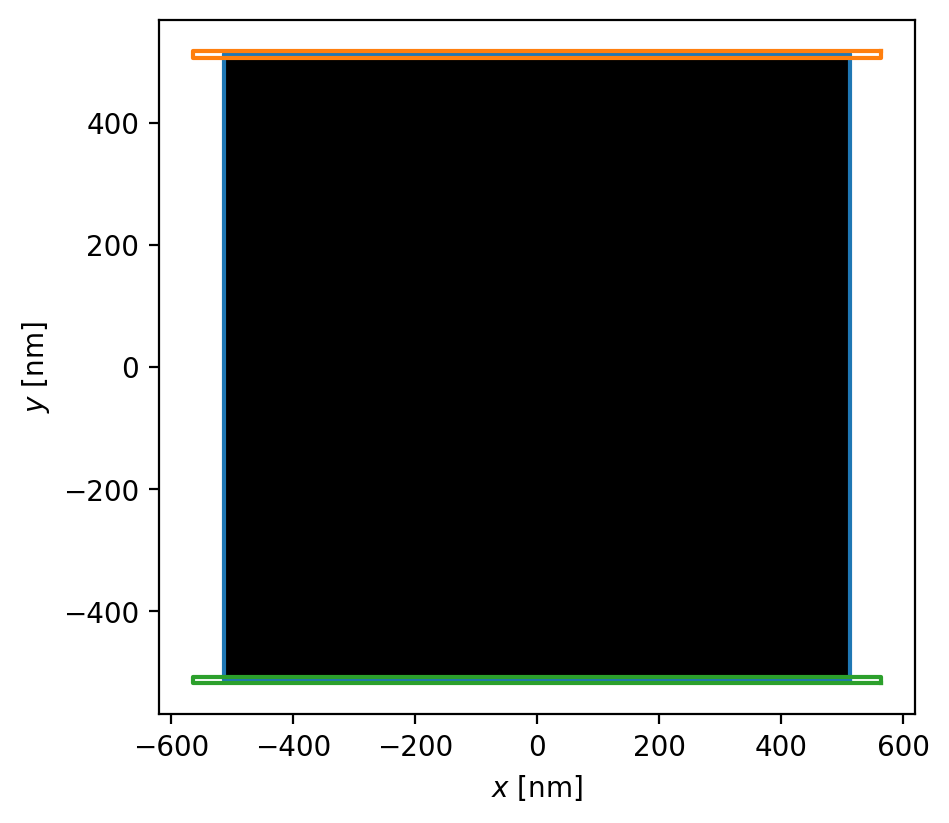

In [24]:
device.make_mesh(max_edge_length=xi / 2, smooth=100)
fig, ax = device.plot(mesh=True, legend=False)

In [25]:
import Field_Definition
import fmfield_z
import importlib
import Animation
importlib.reload(Field_Definition)
importlib.reload(fmfield_z)
importlib.reload(Animation)
from Field_Definition import Field
from fmfield_z import FMField
from Animation import make_video_from_solution
from Animation import plot_order_parameter
from Animation import plot_vorticity
m_outline_filename = "Documents/GitHub/sup-spin/mumax3/kaiyang/Fe3Co7.out/0004_full_mag_90mT_layer2_outline.npy"

In [58]:
options = tdgl.SolverOptions(
    solve_time=100,
    output_file=os.path.join(tempdir.name, "square_ramping_field.h5"),
    field_units = "T",
    current_units="mA",
)
field_multipliers=[0.5]
solution=[]
for m in field_multipliers:
    potential = FMField(multiplier = m)
    solution.append(tdgl.solve(
        device,
        options,
        applied_vector_potential=potential,
        terminal_currents=dict(source=20, drain=-20),
    ))

X range: -5.120000000000001e-07 5.12e-07
Y range: -5.12e-07 5.12e-07


/opt/anaconda3/lib/python3.11/site-packages/scipy/interpolate/_ndgriddata.py:264: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  ip = LinearNDInterpolator(points, values, fill_value=fill_value,
The terminal currents are non-null, but the device has no probe points.
Output file already exists. Renaming to /var/folders/40/tfpdhywx23x_v57wxqb_khl00000gn/T/tmprjd557lj/square_ramping_field-5.h5.
Simulating: 100%|█████████▉| 100/100 [14:24<00:00,  8.64s/tau ]      


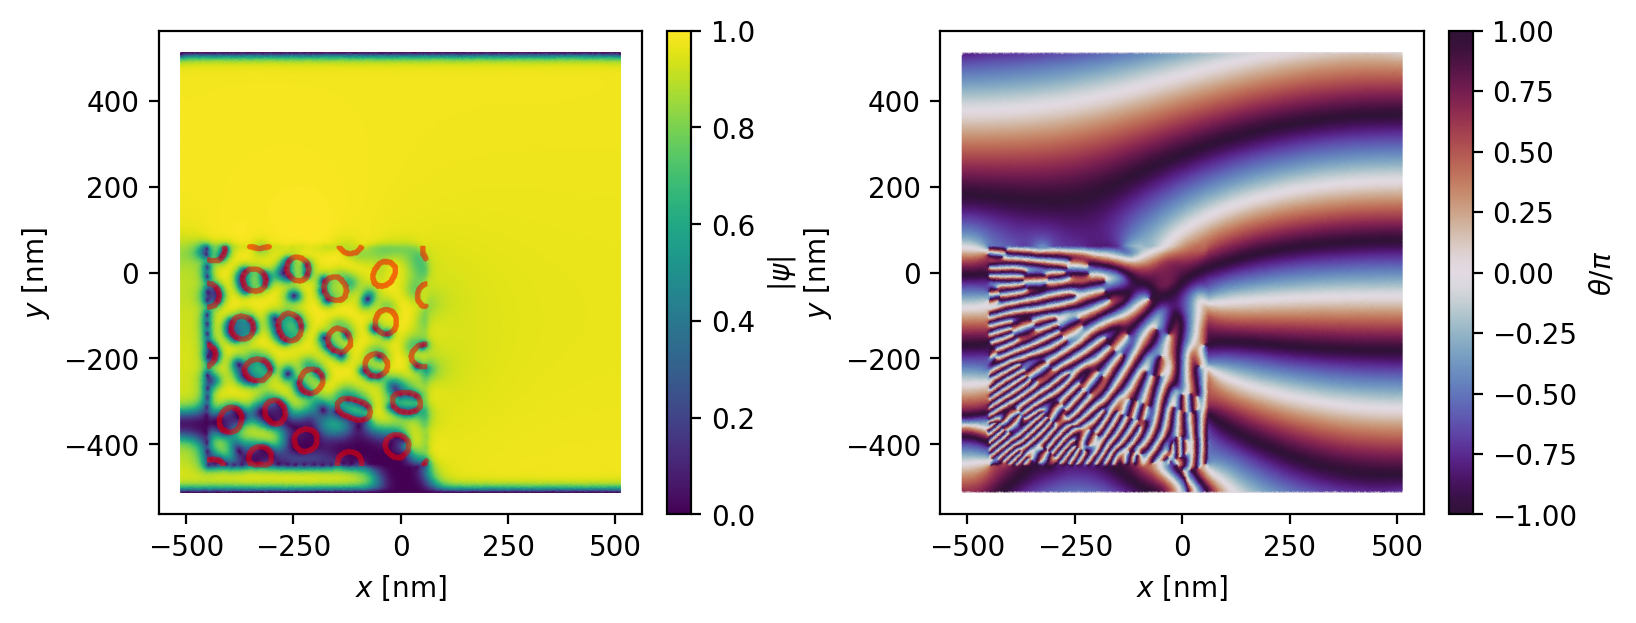

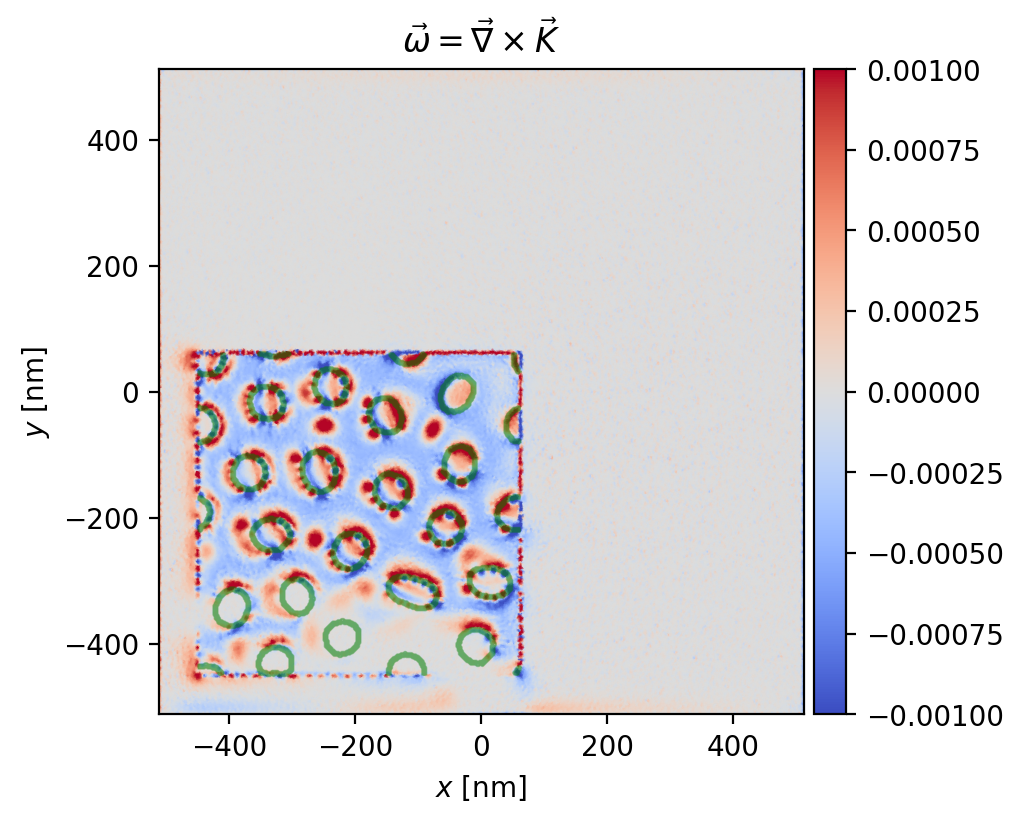

In [59]:
for i in range(1):
    fig, axes1 = plot_order_parameter(solution[i],m_outline_filename)
    fig2, axes2 = plot_vorticity(solution[i],m_outline_filename,vmin=-0.001,vmax=0.001)

In [60]:
MAKE_ANIMATIONS=True
if MAKE_ANIMATIONS:
    mumax_FM_field_video = make_video_from_solution(
        solution[0],
        m_outline_filename,
        quantities=["order_parameter", "vorticity"],
        figsize=(8, 4),
    )
    display(mumax_FM_field_video)

Uniform Seperation